<a href="https://colab.research.google.com/github/RajeshRanaGiet/AML-LAB/blob/main/Experiment%203/exp3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Dataset Summary ---
Shape: (379, 5)

Missing Values:
 SEM 1    0
SEM 2    0
SEM 3    0
SEM 4    0
SEM 5    0
dtype: int64

Stats:
             SEM 1       SEM 2       SEM 3       SEM 4       SEM 5
count  379.000000  379.000000  379.000000  379.000000  379.000000
mean     5.908707    6.015858    6.103852    6.167546    6.050765
std      3.147572    3.139440    3.078922    3.131259    3.091451
min      0.100000    0.100000    0.130000    0.120000    0.140000
25%      4.080000    4.275000    4.870000    4.990000    4.290000
50%      7.150000    7.240000    7.500000    7.450000    7.420000
75%      8.190000    8.320000    8.225000    8.440000    8.220000
max      9.800000    9.880000    9.730000    9.880000    9.640000


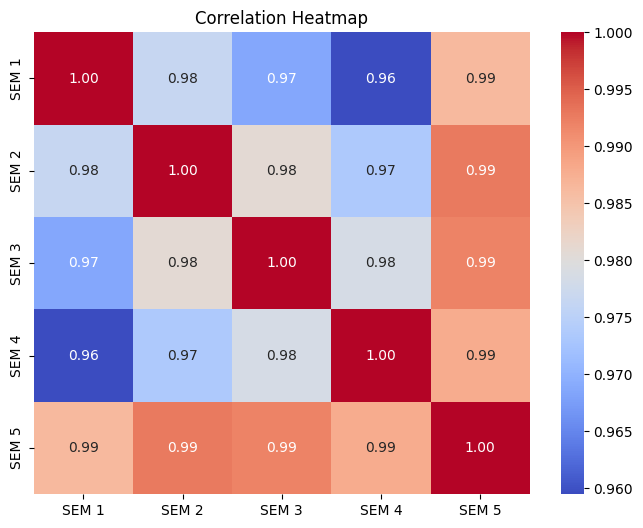

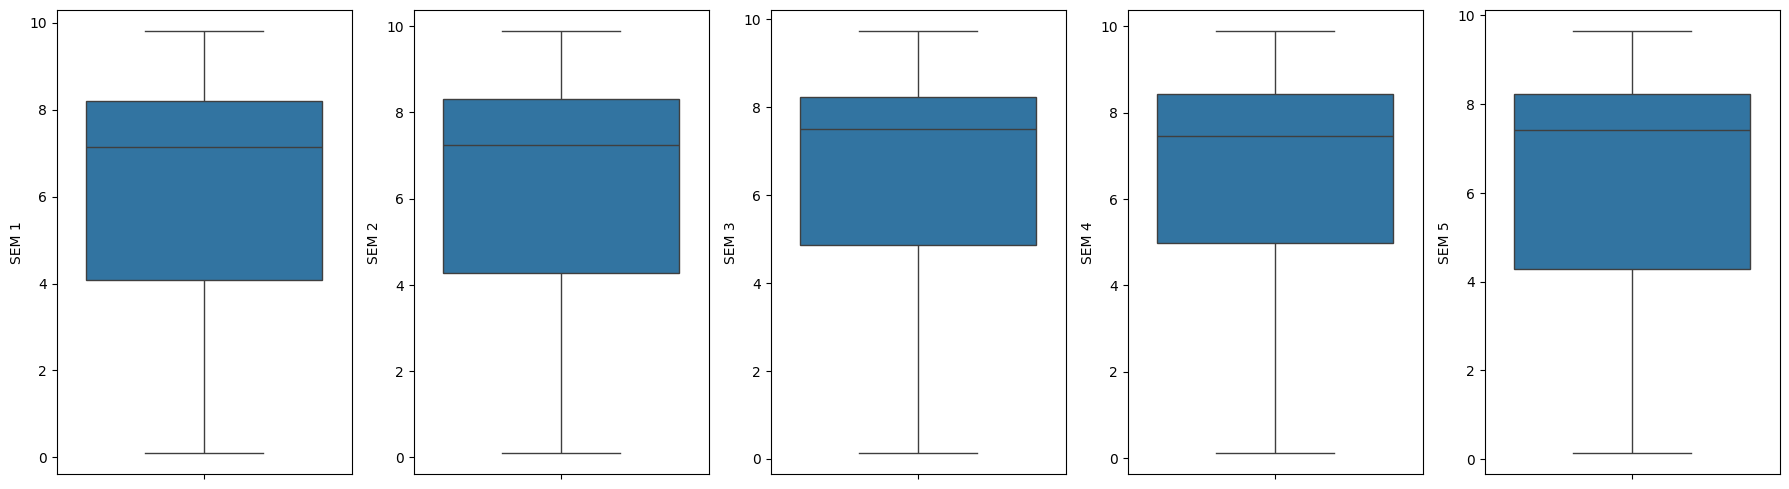


Top correlated feature with SEM 5 is: 'SEM 2'

--- Simple Linear Regression ---
Equation: y = 0.1694 + 0.9786 * SEM 2
MSE: 0.1175 | MAE: 0.2454 | RMSE: 0.3428 | R²: 0.9887


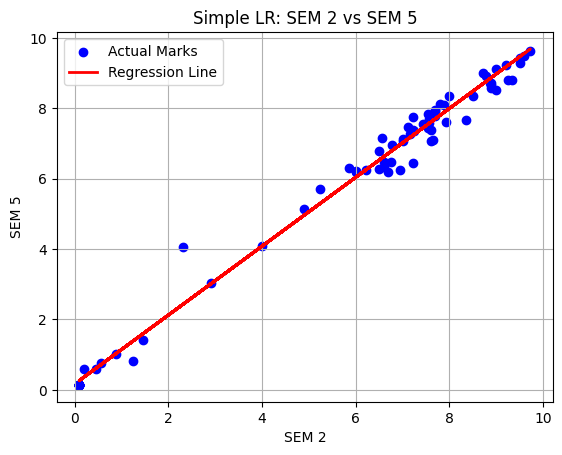

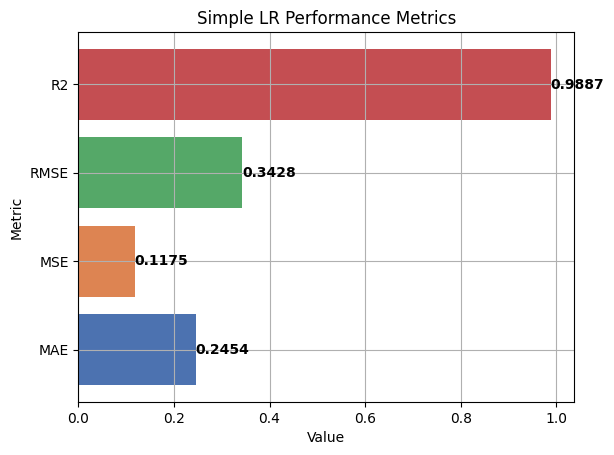


--- Multiple Linear Regression ---
Equation: y = 0.0036 + 0.2499 * SEM 1 + 0.2502 * SEM 2 + 0.2499 * SEM 3 + 0.2497 * SEM 4
MSE: 0.0000 | MAE: 0.0023 | RMSE: 0.0027 | R²: 1.0000


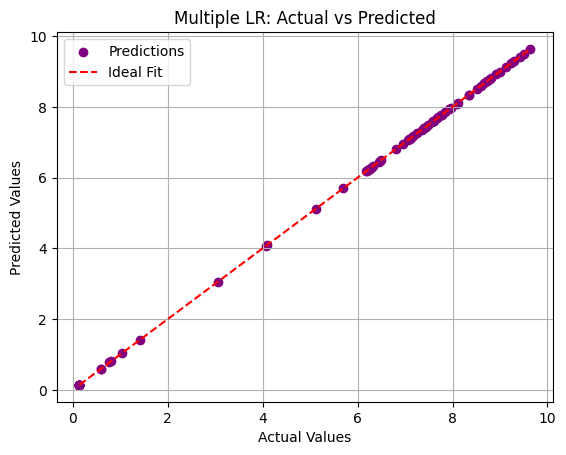

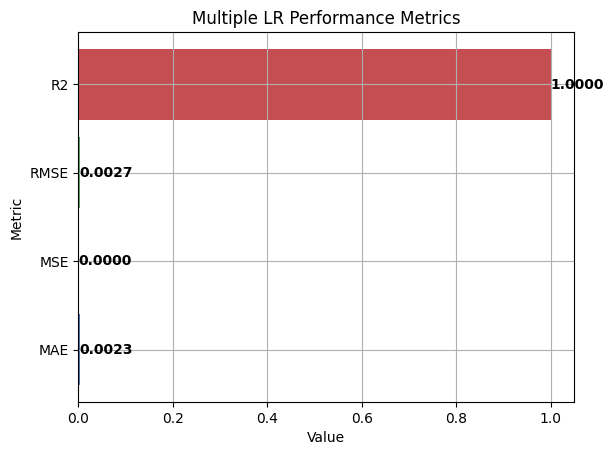


--- Enter Marks to Predict SEM 5 ---
Enter 1st Semester marks: 9
Enter 2nd Semester marks: 7
Enter 3rd Semester marks: 8
Enter 4th Semester marks: 9

The predicted 5th Semester mark is: 8.25


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


def train_and_evaluate(X, y, title):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LinearRegression()
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)
    equation = f"y = {model.intercept_:.4f}"
    for coef, col in zip(model.coef_, X.columns):
        equation += f" + {coef:.4f} * {col}"
    print(f"\n--- {title} ---")
    print(f"Equation: {equation}")
    print(f"MSE: {mse:.4f} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f}")
    return model, X_test, y_test, predictions, [mae, mse, rmse, r2]


def plot_chart(chart_type, x_data, y_data, title, xlabel, ylabel, predictions=None):
    if chart_type == 'scatter_line':
        plt.scatter(x_data, y_data, color='blue', label='Actual Marks')
        plt.plot(x_data, predictions, color='red', linewidth=2, label='Regression Line')
        plt.legend()
    elif chart_type == 'actual_vs_pred':
        plt.scatter(x_data, y_data, color='purple', label='Predictions')
        plt.plot([x_data.min(), x_data.max()], [x_data.min(), x_data.max()], 'r--', label='Ideal Fit')
        plt.legend()
    elif chart_type == 'metrics_bar':
        bars = plt.barh(["MAE", "MSE", "RMSE", "R2"], x_data, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
        for bar in bars:
            width = bar.get_width()
            plt.annotate(f"{width:.4f}", xy=(width, bar.get_y() + bar.get_height() / 2), ha="left", va="center", fontweight="bold")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.show()


url = 'https://raw.githubusercontent.com/RajeshRanaGiet/AML-LAB/main/Experiment%203/studentGradeDataSet.csv'
data = pd.read_csv(url)

print("--- Dataset Summary ---")
print("Shape:", data.shape)
print("\nMissing Values:\n", data.isnull().sum())
print("\nStats:\n", data.describe())

features = ['SEM 1', 'SEM 2', 'SEM 3', 'SEM 4']
X_all = data[features]
y = data['SEM 5']

plt.figure(figsize=(8, 6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

fig, axes = plt.subplots(1, len(data.columns), figsize=(18, 5))
for i, col in enumerate(data.columns):
    sns.boxplot(y=data[col], ax=axes[i])
plt.tight_layout()
plt.show()

best_feature = X_all.corrwith(y).abs().idxmax()
print(f"\nTop correlated feature with SEM 5 is: '{best_feature}'")

X_simple = data[[best_feature]]
simple_model, X_test_s, y_test_s, pred_s, metrics_s = train_and_evaluate(X_simple, y, 'Simple Linear Regression')

plot_chart('scatter_line', X_test_s, y_test_s, f'Simple LR: {best_feature} vs SEM 5', best_feature, 'SEM 5', pred_s)
plot_chart('metrics_bar', metrics_s, None, 'Simple LR Performance Metrics', 'Value', 'Metric')

multi_model, X_test_m, y_test_m, pred_m, metrics_m = train_and_evaluate(X_all, y, 'Multiple Linear Regression')

plot_chart('actual_vs_pred', y_test_m, pred_m, 'Multiple LR: Actual vs Predicted', 'Actual Values', 'Predicted Values')
plot_chart('metrics_bar', metrics_m, None, 'Multiple LR Performance Metrics', 'Value', 'Metric')

print("\n--- Enter Marks to Predict SEM 5 ---")
s1 = float(input("Enter 1st Semester marks: "))
s2 = float(input("Enter 2nd Semester marks: "))
s3 = float(input("Enter 3rd Semester marks: "))
s4 = float(input("Enter 4th Semester marks: "))

user_input = pd.DataFrame([{"SEM 1": s1, "SEM 2": s2, "SEM 3": s3, "SEM 4": s4}])
predicted_mark = multi_model.predict(user_input)[0]
print(f"\nThe predicted 5th Semester mark is: {predicted_mark:.2f}")